# Facial Keypoints Detection

-  The marking of important areas of the face, such as the eyes, corners of the mouth, and nose, that are relevant for a variety of tasks, such as face filters, emotion recognition, and pose recognition, using convolutional neural network and computer vision techniques to perform facial Keypoint detection.

-  It entails forecasting the Facial Key points coordinates for a particular face, such as nose tip, the center of eyes, and so on. To recognize facial key points, we use a Convolutional Neural Network-based model using Autoencoders.

-  Convolutional Neural Networks (CNN) has a deep structure that allows them to extract high-level information and provide better precision when identifying each important point. Convolutional networks are designed to anticipate all points at the same time.

In [4]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

In [5]:
train = pd.read_csv('training.csv')
test = pd.read_csv('test.csv')

In [6]:
train.head()

,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,right_eye_inner_corner_y,...,nose_tip_y,mouth_left_corner_x,mouth_left_corner_y,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y,Image
0,66.033564,39.002274,30.227008,36.421678,59.582075,39.647423,73.130346,39.969997,36.356571,37.389402,...,57.066803,61.195308,79.970165,28.614496,77.388992,43.312602,72.935459,43.130707,84.485774,238 236 237 238 240 240 239 241 241 243 240 23...
1,64.332936,34.970077,29.949277,33.448715,58.856170,35.274349,70.722723,36.187166,36.034723,34.361532,...,55.660936,56.421447,76.352000,35.122383,76.047660,46.684596,70.266553,45.467915,85.480170,219 215 204 196 204 211 212 200 180 168 178 19...
2,65.057053,34.909642,30.903789,34.909642,59.412000,36.320968,70.984421,36.320968,37.678105,36.320968,...,53.538947,60.822947,73.014316,33.726316,72.732000,47.274947,70.191789,47.274947,78.659368,144 142 159 180 188 188 184 180 167 132 84 59 ...
3,65.225739,37.261774,32.023096,37.261774,60.003339,39.127179,72.314713,38.380967,37.618643,38.754115,...,54.166539,65.598887,72.703722,37.245496,74.195478,50.303165,70.091687,51.561183,78.268383,193 192 193 194 194 194 193 192 168 111 50 12 ...
4,66.725301,39.621261,32.244810,38.042032,58.565890,39.621261,72.515926,39.884466,36.982380,39.094852,...,64.889521,60.671411,77.523239,31.191755,76.997301,44.962748,73.707387,44.227141,86.871166,147 148 160 196 215 214 216 217 219 220 206 18...


# Check for null values

In [7]:
print(f'Feature \t\t\t Missing \t Percentage missing\n')
for k,v in train.isna().sum().items():
    print(f'{k !s:30} :{v :8} \t {round(v/len(train),2)}%')

Feature 			 Missing 	 Percentage missing

left_eye_center_x              :      10 	 0.0%
left_eye_center_y              :      10 	 0.0%
right_eye_center_x             :      13 	 0.0%
right_eye_center_y             :      13 	 0.0%
left_eye_inner_corner_x        :    4778 	 0.68%
left_eye_inner_corner_y        :    4778 	 0.68%
left_eye_outer_corner_x        :    4782 	 0.68%
left_eye_outer_corner_y        :    4782 	 0.68%
right_eye_inner_corner_x       :    4781 	 0.68%
right_eye_inner_corner_y       :    4781 	 0.68%
right_eye_outer_corner_x       :    4781 	 0.68%
right_eye_outer_corner_y       :    4781 	 0.68%
left_eyebrow_inner_end_x       :    4779 	 0.68%
left_eyebrow_inner_end_y       :    4779 	 0.68%
left_eyebrow_outer_end_x       :    4824 	 0.68%
left_eyebrow_outer_end_y       :    4824 	 0.68%
right_eyebrow_inner_end_x      :    4779 	 0.68%
right_eyebrow_inner_end_y      :    4779 	 0.68%
right_eyebrow_outer_end_x      :    4813 	 0.68%
right_eyebrow_outer_end_y      

In [8]:
train.fillna(method = 'ffill', inplace = True)
"""
fillna() to replace missing values with 
the last valid observation in the column, 
i.e., to use a forward fill method
"""

'\nfillna() to replace missing values with \nthe last valid observation in the column, \ni.e., to use a forward fill method\n'

In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7049 entries, 0 to 7048
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   left_eye_center_x          7049 non-null   float64
 1   left_eye_center_y          7049 non-null   float64
 2   right_eye_center_x         7049 non-null   float64
 3   right_eye_center_y         7049 non-null   float64
 4   left_eye_inner_corner_x    7049 non-null   float64
 5   left_eye_inner_corner_y    7049 non-null   float64
 6   left_eye_outer_corner_x    7049 non-null   float64
 7   left_eye_outer_corner_y    7049 non-null   float64
 8   right_eye_inner_corner_x   7049 non-null   float64
 9   right_eye_inner_corner_y   7049 non-null   float64
 10  right_eye_outer_corner_x   7049 non-null   float64
 11  right_eye_outer_corner_y   7049 non-null   float64
 12  left_eyebrow_inner_end_x   7049 non-null   float64
 13  left_eyebrow_inner_end_y   7049 non-null   float

#### The input image is given in the last field of the data files, and consists of a list of pixels (ordered by row), as integers in (0,255). The images are 96x96 pixels.

In [10]:
train['Image'].head()

0    238 236 237 238 240 240 239 241 241 243 240 23...
1    219 215 204 196 204 211 212 200 180 168 178 19...
2    144 142 159 180 188 188 184 180 167 132 84 59 ...
3    193 192 193 194 194 194 193 192 168 111 50 12 ...
4    147 148 160 196 215 214 216 217 219 220 206 18...
Name: Image, dtype: object

In [11]:
len(train)

7049

In [12]:
imag = []    #list of lists(contains pixel values for images)
for i in range(0, 7049):
    img = train['Image'][i].split(' ')
    img = ['0' if x=='' else x for x in img]
    imag.append(img)

In [13]:
image_list = np.array(imag, dtype = 'float')
X_train = image_list.reshape(-1, 96, 96, 1)
targets = np.array(train.iloc[:, :-1])

In [14]:
print('Shape of images',X_train.shape)
print('Shape of targets',targets.shape)

Shape of images (7049, 96, 96, 1)
Shape of targets (7049, 30)


In [15]:
# lets create an util that will display the images
def display_images(img, feat):
    plt.imshow(img, cmap=plt.cm.gray);
    plt.scatter(feat[0::2], feat[1::2], c='r', marker='x')
    

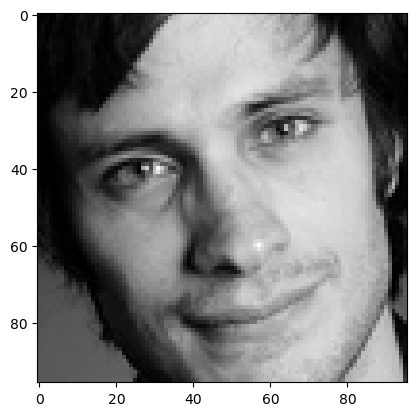

In [16]:
plt.imshow(X_train[2282].reshape(96,96), cmap = 'gray')
plt.show()

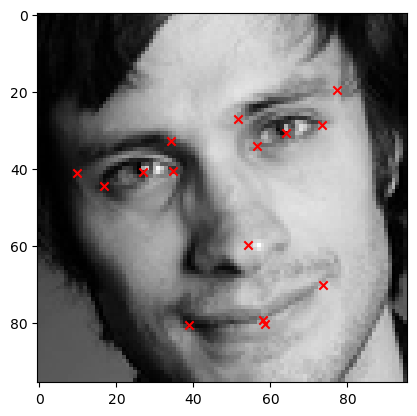

In [17]:
##### lets test visualization
display_images(X_train[2282], targets[2282])

## Augmentation
We can add different augmenations like -

*  flipping
*  rotation
*  cropping
*  adding noise
*  bluring
*  brightness

etc..



In [18]:
# lets create an util to display the augumentation
def display_augmentation(img, feat, img_f, feat_f):
    plt.figure(figsize=(8,8))
    plt.subplot(2,2,1)
    plt.scatter(feat[0::2],-feat[1::2],c='r',marker='x')
    plt.subplot(2,2,2)
    plt.scatter(feat_f[0::2],-feat_f[1::2],c='r',marker='x')
    plt.subplot(2,2,3)
    display_images(img, feat)
    plt.subplot(2,2,4)
    display_images(img_f, feat_f)

In [19]:
# sample image to test augmentation
image, feature = X_train[2282].copy(), targets[2282].copy()

### Flipping

In [20]:
flipped_img = np.fliplr(image)

In [21]:
flipped_feat = feature.copy()
for i, v in enumerate(feature):
    # we dont want to flip y-axis , we just want to flip x-axis
    if i % 2 ==0:
        v = 96-v
    flipped_feat[i]=v

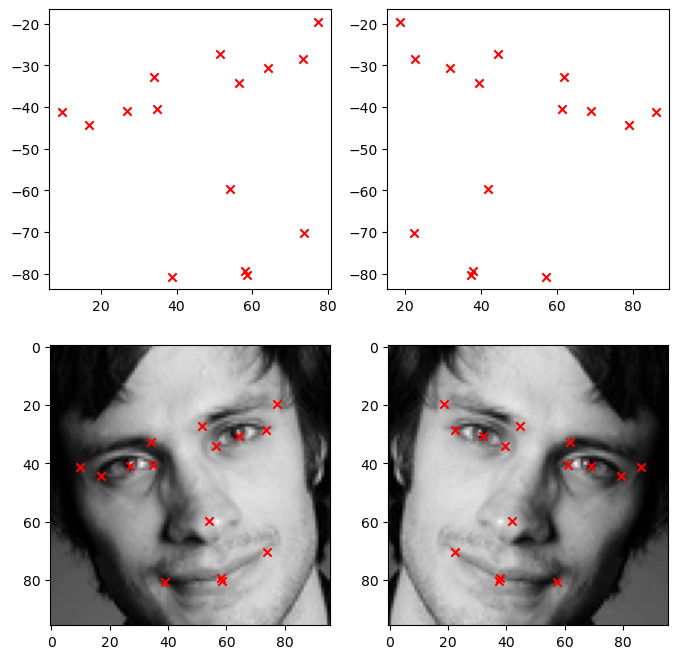

In [22]:
display_augmentation(image, feature, flipped_img, flipped_feat)

In [23]:
# lets make an util that give us flipped images and targets
def flipping_augmentation(images, features):
    flipped_images = np.flip(images, axis=2)
    
    flipped_features = features.copy()
    for i, feat in enumerate(flipped_features):
        for j, val in enumerate(feat):
            if j%2==0:
                flipped_features[i][j] = 96-val
            
    return flipped_images, flipped_features

# let create an object to keep track of the augmentations
augmentation_functions = {
    'flip' : flipping_augmentation
}

In [24]:
# lets see one more example
flip_imgs, flip_feats = flipping_augmentation(X_train[:5], targets[:5])

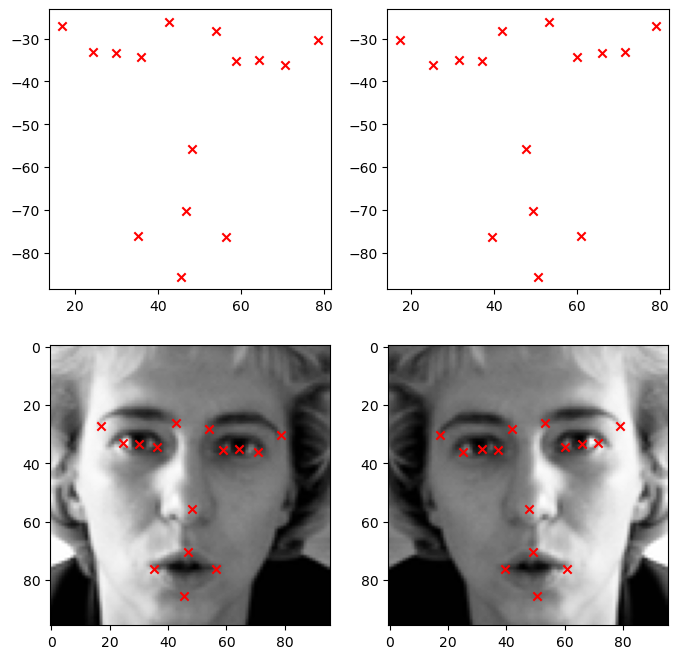

In [25]:
display_augmentation(X_train[1], targets[1], flip_imgs[1],flip_feats[1])

### Cropping 

In [26]:
cropped_image = image.copy()

cropped_image[:,:10] = 0
cropped_image[:,86:] = 0
cropped_image[:10,:] = 0
cropped_image[86:,:] = 0


cropped_image.shape

(96, 96, 1)

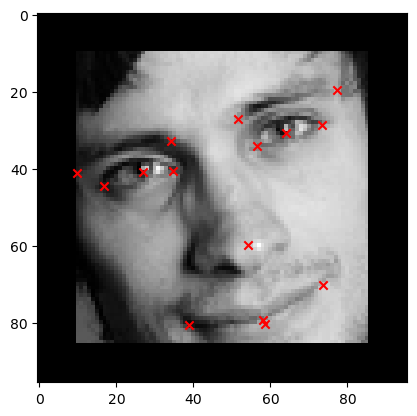

In [27]:
plt.imshow(cropped_image, cmap=plt.cm.gray);
plt.scatter(feature[0::2],feature[1::2],marker='x',c='r');

In [28]:
# lets make an util that give us cropped images and targets
def crop_augmentation(images, targets):
    cropped_images = images.copy()

    for i in range(len(images)):
        cropped_images[i,:,:10] = 0
        cropped_images[i,:,86:] = 0
        cropped_images[i,:10,:] = 0
        cropped_images[i,86:,:] = 0

    return cropped_images, targets


augmentation_functions['crop']=crop_augmentation
    

### Rotation 

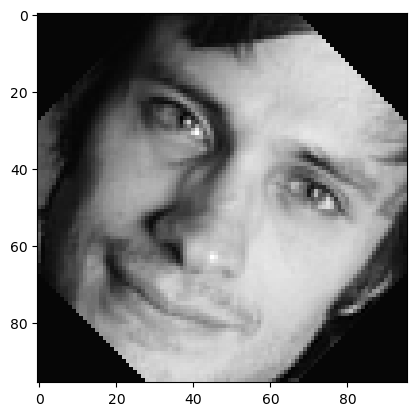

In [29]:
from scipy import ndimage, misc

img_45 = ndimage.rotate(image, -45, reshape=False)
plt.imshow(img_45 , cmap=plt.cm.gray);

In [30]:
def rotate_points(points, angle):
    # shift points in the plane so that the center of rotation is at the origin
    # our image is 96*96 ,so substract 48
    points = points-48

    # rotation matrix
    theta = np.radians(angle)
    c, s = np.cos(theta), np.sin(theta)
    R = np.array(((c, -s), (s, c)))

    # rotate the points
    for i in range(0,len(points),2):
        xy = np.array([points[i],points[i+1]])
        xy_rot = R@xy
        points[i],points[i+1]= xy_rot

    #  shift again so the origin goes back to the desired center of rotation
    points = points+48
    return points

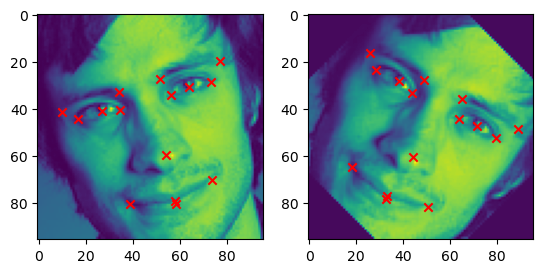

In [31]:
# rotated feature points 
feat_45 = rotate_points(feature, 45)

plt.subplot(121)
plt.imshow(image)
plt.scatter(feature[0::2], feature[1::2], c='r', marker='x')
plt.subplot(122)
plt.imshow(img_45)
plt.scatter(feat_45[0::2], feat_45[1::2], c='r', marker='x');

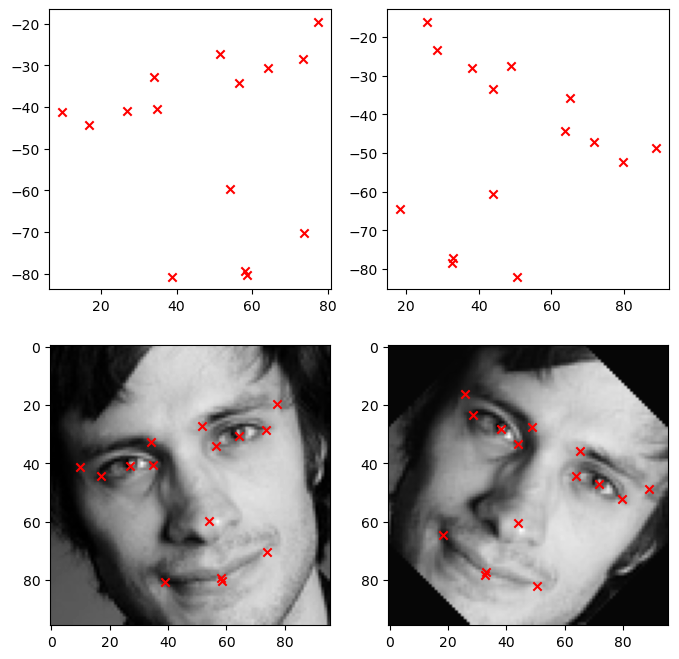

In [32]:
# lets see the rotation

display_augmentation(image, feature, img_45, feat_45)

In [33]:
# lets make an util that give us rotated images and targets

def rotate_augmentation(images, features, angle):
    rotated_images = []
    for img in images:
        img_rot = ndimage.rotate(img, -angle, reshape=False)
        rotated_images.append(img_rot)
        
    rotated_features=[]
    for feat in features:
        feat_rot = rotate_points(feat, angle)
        rotated_features.append(feat_rot)
        

    return np.array(rotated_images), np.array(rotated_features)


augmentation_functions['rotate'] = rotate_augmentation

In [34]:
# check once more using a different angle
img_rot, feat_rot = rotate_augmentation(X_train[:11], targets[:11,:], angle=-45)

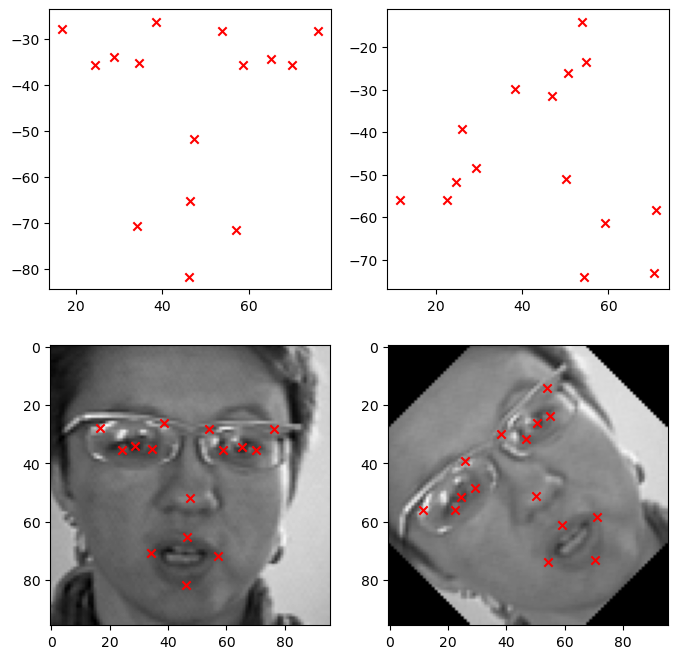

In [35]:
display_augmentation(X_train[10], targets[10], img_rot[10], feat_rot[10])

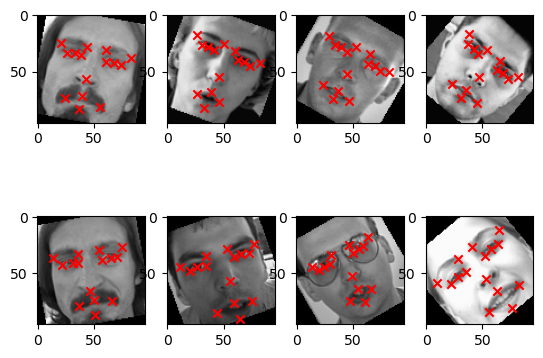

In [36]:
for i,theta in enumerate([10,20,30,40,-10,-20,-30,-40]):
    img, feat = rotate_augmentation(X_train[:10], targets[:10], theta)
    plt.subplot(2,4,i+1)
    display_images(img[i],feat[i])

### Brightness

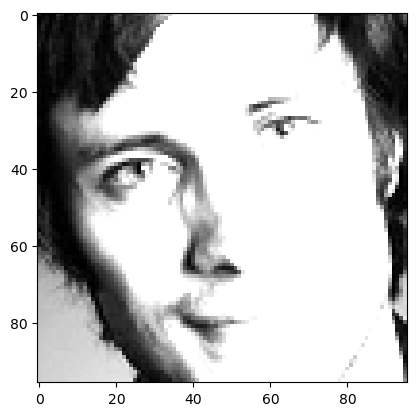

In [37]:
img = image.copy()
img = np.clip(img*2.5,0,255)
plt.imshow(img, cmap='gray');

In [38]:
# lets create an util that adds brightness
def brightness_augmentation(images, features, factor=1.5):
    bright = []
    for img in images:
        bright.append(np.clip(img*factor, 0, 255))
    return np.array(bright), features

augmentation_functions['brightness'] = brightness_augmentation

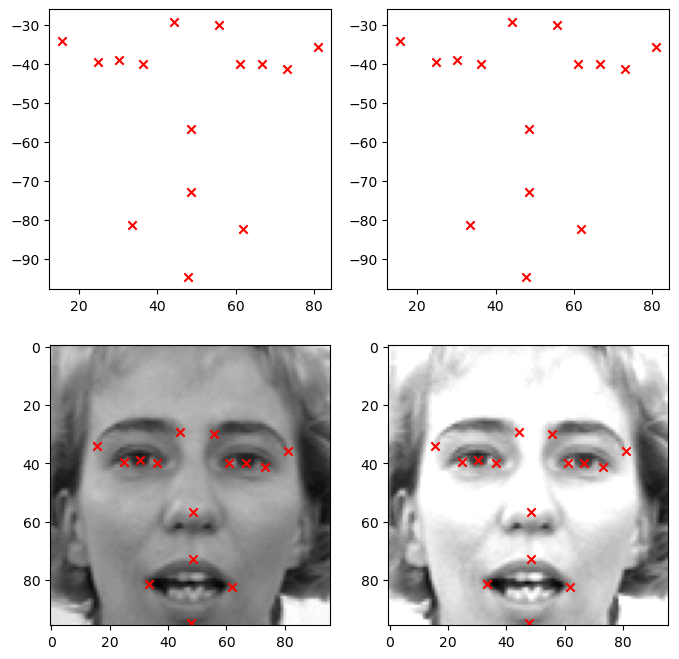

In [39]:
# lets see one more example
img, feat = brightness_augmentation(X_train[:15], targets[:15], factor=2.0)

display_augmentation(X_train[11], targets[11], img[11], feat[11])


### Adding noise 

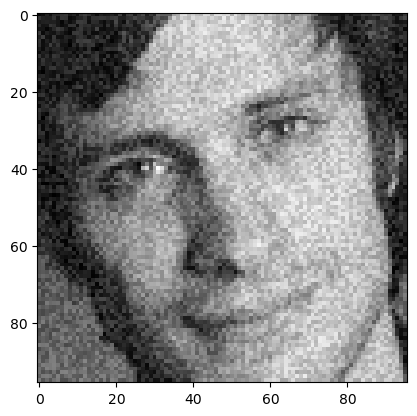

In [40]:
img = image.copy()
noise = np.random.randint(low=0, high=255, size=img.shape)
factor = 0.25
plt.imshow(img+(noise*factor), cmap='gray');

In [41]:
# lets create an utility that adds noise to the image
def noise_augmentation(images, features, factor):
    augmented = []
    noise = np.random.randint(low=0, high=255, size=images.shape[1:])
    for img in images:
        img = img + (noise*factor)
        augmented.append(img)
    
    return np.array(augmented), features

augmentation_functions['noise'] = noise_augmentation

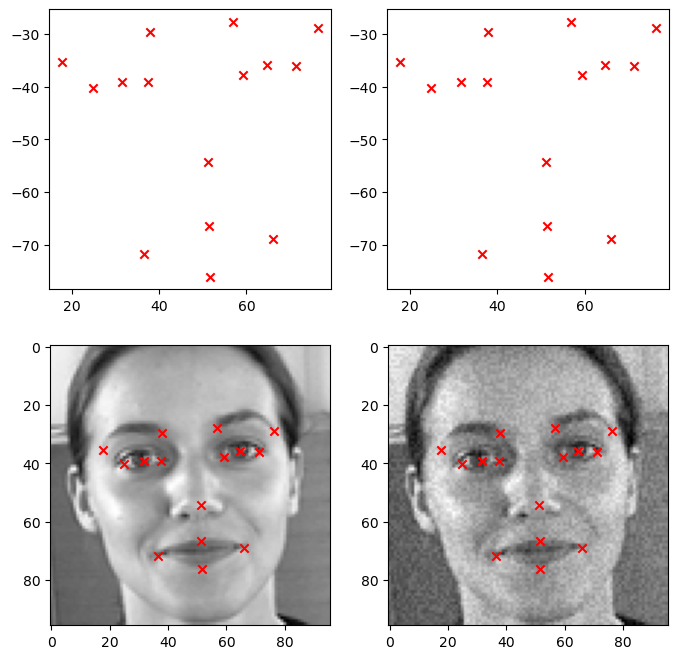

In [42]:
# lets see one another example
img, feat = noise_augmentation(X_train[:25], targets[:25], factor=0.15)

display_augmentation(X_train[23], targets[23], img[23], feat[23])

### Lets prepare our training data

In [44]:
print('Shape of image data',X_train.shape)
print('Shape of target data', targets.shape)

Shape of image data (7049, 96, 96, 1)
Shape of target data (7049, 30)


In [45]:
# ADDING AUGMENTATION

def augmentation(img, feat , method):
    aug_img, aug_feat = method
    img = np.concatenate([img,aug_img])
    feat = np.concatenate([feat,aug_feat])
    return img, feat


# flip
method = flipping_augmentation(X_train, targets)
augmented_images, augmented_targets = augmentation(X_train, targets, method)
print('image augmentation : flipping')

# crop
method = crop_augmentation(X_train, targets)
augmented_images, augmented_targets = augmentation(augmented_images, augmented_targets, method)
print('image augmentation : cropping')

# rotate
for theta in [10,12,15,-10,-12,-15]:
    method = rotate_augmentation(X_train, targets, angle=theta)
    augmented_images, augmented_targets = augmentation(augmented_images, augmented_targets, method)
print('image augmentation : rotation')


# brightness
method = brightness_augmentation(X_train, targets, factor=2.0)
augmented_images, augmented_targets = augmentation(augmented_images, augmented_targets, method)
print('image augmentation : adding brightness')


# noise
method = noise_augmentation(X_train, targets, factor=0.2)
augmented_images, augmented_targets = augmentation(augmented_images, augmented_targets, method)
print('image augmentation : adding noise')


image augmentation : flipping
image augmentation : cropping
image augmentation : rotation


KeyboardInterrupt: 

In [ ]:
print('Shape of data after augmentation')
print('Shape of image data',augmented_images.shape)
print('Shape of target data', augmented_targets.shape)

In [ ]:
# lets check our data one last time before we start building models

def visualize_data(images, targets):
    plt.figure(figsize=(12,12))
    for i in range(10):
        idx = np.random.randint(images.shape[0])
        plt.subplot(2,5,i+1)
        display_images(images[idx], targets[idx])
        plt.axis('off')
    plt.subplots_adjust(bottom=0.5)
    plt.show()

visualize_data(augmented_images, augmented_targets)

### Modeling
MobileNetV2 is very similar to the original MobileNet, except that it uses inverted residual blocks with bottlenecking features. It has a drastically lower parameter count than the original MobileNet. MobileNets support any input size greater than 32 x 32, with larger image sizes offering better performance.

 

In [ ]:
pretrained_model = tf.keras.applications.mobilenet_v2.MobileNetV2(input_shape=(96,96,3),include_top=False,weights='imagenet')
# pretrained_model = tf.keras.applications.resnet_v2.ResNet50V2(input_shape=(96,96,3),include_top=False,weights='imagenet')


Each Keras Application expects a specific kind of input preprocessing. For MobileNetV2, call tf.keras.applications.mobilenet_v2.preprocess_input on your inputs before passing them to the model. mobilenet_v2.preprocess_input will scale input pixels between -1 and 1.

In [ ]:
%%time
augmented_images = tf.keras.applications.mobilenet_v2.preprocess_input(augmented_images)
# augmented_images = tf.keras.applications.resnet_v2.preprocess_input(augmented_images)

In [ ]:
%%time

# lets check our data to make sure everything is fine

visualize_data(augmented_images,augmented_targets)

In [ ]:
# lets create a dataset for training and validation
ds = tf.data.Dataset.from_tensor_slices((augmented_images,augmented_targets))
ds = ds.shuffle(buffer_size=augmented_targets.shape[0])
ds = ds.batch(64)
ds = ds.prefetch(tf.data.AUTOTUNE)

In [ ]:
train_ds = ds.skip(10).shuffle(100)
val_ds = ds.take(10)

In [ ]:
# create a preprocessing layer
class ImageTile(tf.keras.layers.Layer):
    def __init__(self):
        super().__init__(trainable = False)
        
    def call(self, inputs):
        return tf.tile(inputs,tf.constant([1,1,1,3]))


In [ ]:
def FFNN(units):
    return tf.keras.Sequential([
        tf.keras.layers.Dense(units),  
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
    ])


In [ ]:
block = []
for units in [512,256,128,64]:
    block.append(FFNN(units))

In [ ]:
model = tf.keras.Sequential([
    
    tf.keras.Input(shape=(96,96,1)),
    
    ImageTile(),
    
    pretrained_model,
    
    tf.keras.layers.GlobalMaxPooling2D(),
    
    *block,

    tf.keras.layers.Dense(30)

    
])

In [ ]:
model.layers[1].trainable=False

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.MeanSquaredError(),
              metrics=['accuracy', 'mae', 'mse'])

In [ ]:
model.summary()

In [ ]:
import math
# decaying learing rate
def decay_lr(epoch):
  return 0.01*math.pow(0.77,epoch)

lr_schedule = tf.keras.callbacks.LearningRateScheduler(decay_lr)

lr_on_plateau = tf.keras.callbacks.ReduceLROnPlateau(patience=2)
    
    
early_stopping = tf.keras.callbacks.EarlyStopping(
                        monitor='val_loss',
                        patience=3,
                        restore_best_weights=True)

In [ ]:
history = model.fit(train_ds, epochs=20, 
                    validation_data=val_ds, 
                    callbacks=[early_stopping,lr_on_plateau])

In [ ]:
test.head()

In [ ]:
test_images = get_images(test)
test_images = tf.keras.applications.mobilenet_v2.preprocess_input(test_images)
test_ds = tf.data.Dataset.from_tensor_slices((test_images)).batch(64)

### Predictions 

In [ ]:
test_preds = model.predict(test_ds)

In [ ]:
print('Shape of test predictions', test_preds.shape)

In [ ]:
display_images(test_images[0],test_preds[0])

In [ ]:
visualize_data(test_images,test_preds)

In [ ]:
visualize_data(test_images,test_preds) 

### Fine tune the model
Now that our model is trained, Lets fine tune it

In [ ]:
# how many layers are there in the pre-trained model ?
print('Layers in pre-trained model' ,len(model.layers[1].layers))

# these layers are not trainable, we set trainable = False in the begining
# lets make some of the top layers trainable

In [ ]:
model.layers[1].trainable = True

In [ ]:
for layer in model.layers[1].layers[:-50]:
    layer.trainable=False

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.MeanSquaredError(),
              metrics=['accuracy', 'mae', 'mse'])

In [ ]:
model.summary()

In [ ]:
lr_on_plateau = tf.keras.callbacks.ReduceLROnPlateau(patience=2)

early_stopping = tf.keras.callbacks.EarlyStopping(
                        monitor='val_loss',
                        patience=3,
                        restore_best_weights=True)


history = model.fit(train_ds, epochs=10, 
                    validation_data=val_ds, 
                    callbacks=[early_stopping,lr_on_plateau])

In [ ]:
#  prediction after fine-tuning

In [ ]:
test_preds = model.predict(test_ds)

In [ ]:
display_images(test_images[0],test_preds[0])

In [ ]:
visualize_data(test_images,test_preds)

In [ ]:
visualize_data(test_images,test_preds)  

In [ ]:
visualize_data(test_images,test_preds) 

In [ ]:
visualize_data(test_images,test_preds)  

In [ ]:
#train.drop('Image', axis = 1, inplace = True)

In [ ]:
#train.describe()

In [ ]:
# train_y = train.to_numpy()
# train_y.shape

In [ ]:
# from keras.layers import LeakyReLU
# from keras.models import Sequential, Model
# from keras.layers import Activation, Convolution2D, MaxPooling2D,BatchNormalization, Flatten, Dense, Dropout, Conv2D, MaxPool2D, ZeroPadding2D

In [46]:
# #from keras import Sequential, optimizers
# #from keras.layers import Embedding, LSTM, Bidirectional, ConvLSTM2D, GRU, SimpleRNN, RNN
# #from keras import regularizers
# #from keras.layers.core import Activation, Dropout, Dense
# from keras.layers import GlobalMaxPooling1D, Conv1D, MaxPooling1D, Conv2D, MaxPooling2D

In [ ]:
# model = Sequential()
# model.add((Conv2D(filters=128, kernel_size=4, input_shape=(96,96,1), activation='relu', padding='same')))
# model.add(Dense(64, activation= 'relu'))
# model.add(Conv2D(32, 4, activation='relu'))
# model.add(Dense(32, activation='relu'))
# model.add(Conv2D(16, 4, activation='relu'))
# model.add(Conv2D(32, 4, activation='relu'))
# model.add(Conv2D(32, 4, activation='relu'))
# model.add((MaxPooling2D(pool_size=(4, 4))))

# model.add(Flatten())

In [ ]:
# opt = optimizers.Adam(learning_rate = 0.0001)
# model.compile(optimizer = opt, loss='mean_squared_logarithmic_error', metrics=['msle'])


In [ ]:
# model.build()
# model.summary()

In [ ]:
# test.head()

In [ ]:
# image = []
# for i in range(0, len(test)):
#     img = test['Image'][i].split(' ')
#     img = ['0' if x=='' else x for x in img]
#     image.append(img)

In [ ]:
# image_list = np.array(image, dtype = 'float')
# X_train = image_list.reshape(-1, 96, 96, 1)

In [ ]:
# plt.imshow(X_train[0].reshape(96, 96), cmap = 'gray')
# plt.show()

In [ ]:
# pred = model.predict(X_train)
# pred

In [ ]:
# Idlookup

In [ ]:
# lookid_list = list(Idlookup['FeatureName'])
# imageID = list(Idlookup['ImageId']-1)
# pre_list = list(pred)

In [ ]:
# rowid = Idlookup['RowId']
# rowid = list(rowid)

In [ ]:
# feature = []
# for f in list(Idlookup['FeatureName']):
#     feature.append(lookid_list.index(f))

In [ ]:
#feature

In [ ]:
# preded = []
# for x, y in zip(imageID, feature):
#     preded.append(pre_list[x][y])

In [ ]:
# rowid = pd.Series(rowid, name = 'RowId')
# loc = pd.Series(preded, name='Location')
# s = pd.concat([rowid, loc], axis = 1)
# s